In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_openml

# 1.读取数据
boston = fetch_openml(name='boston', version=1, as_frame=True)
X, y = boston.data, boston.target

# 2.数据标准化 & 拆分训练/测试集
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 3.训练贝叶斯回归模型
model = BayesianRidge(tol=1e-6, alpha_1=1e-6, lambda_1=1e-6)  # 优化收敛阈值 先验依赖强度(噪声,系数)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 4.计算误差指标
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE:{mse:.3f}, R^2:{r2:.3f}")

MSE:24.427, R^2:0.667


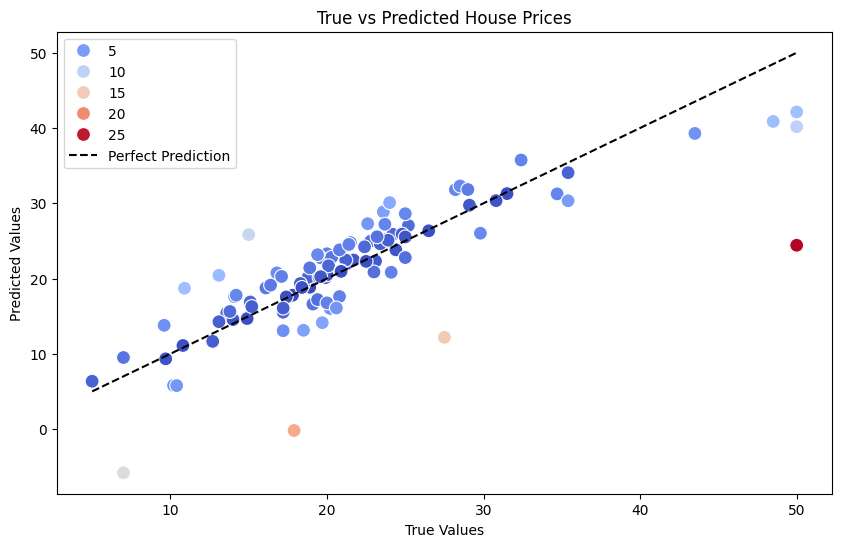

In [12]:
# 5.可视化
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred, hue=np.abs(y_test - y_pred), palette='coolwarm', s=100)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--k', label='Perfect Prediction')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('True vs Predicted House Prices')
plt.legend()
plt.show()

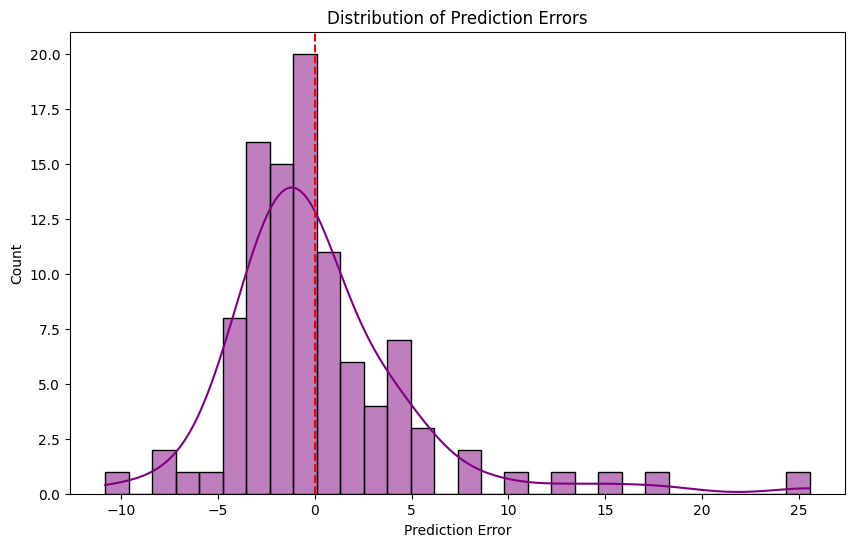

In [13]:
# 6. 误差分布
plt.figure(figsize=(10, 6))
sns.histplot(y_test - y_pred, kde=True, bins=30, color='purple')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Prediction Error')
plt.title('Distribution of Prediction Errors')
plt.show()

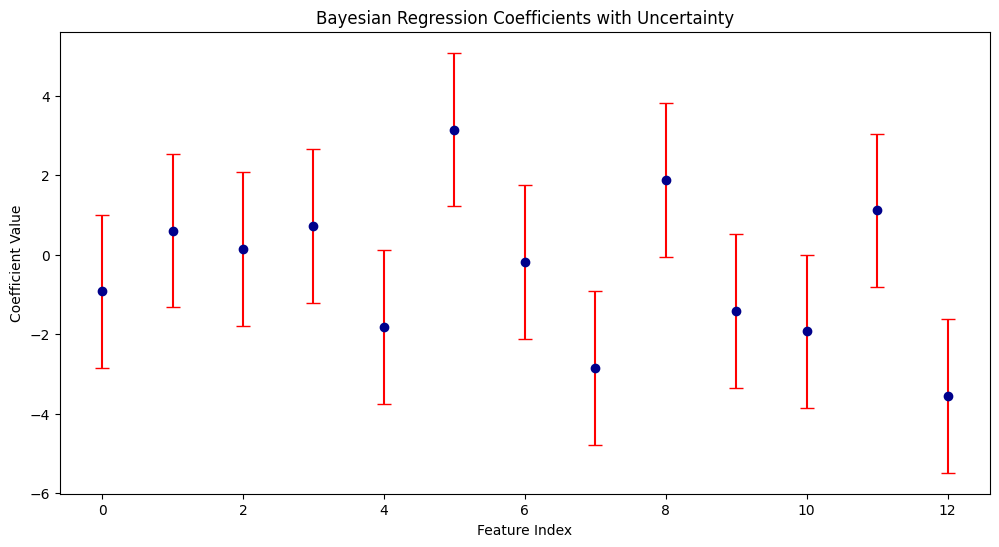

In [14]:
# 7. 置信区间可视化
coefs_mean = model.coef_
coefs_std = np.sqrt(1 / model.lambda_)

plt.figure(figsize=(12, 6))
plt.errorbar(range(len(coefs_mean)), coefs_mean, yerr=coefs_std, fmt='o', color='darkblue', ecolor='red', capsize=5)
plt.xlabel('Feature Index')
plt.ylabel('Coefficient Value')
plt.title('Bayesian Regression Coefficients with Uncertainty')
plt.show()

## 贝叶斯回归在小数据集、不确定性估计、动态更新等方面表现优越